In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare, kstest, pearsonr, spearmanr, kendalltau

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving exoplanet_data.csv to exoplanet_data.csv


In [ ]:
df = pd.read_csv("exoplanet_data.csv", skiprows=range(0, 96))

In [ ]:
columns = [
    "pl_bmassj",   # Planet mass
    "pl_orbper",   # Orbital period
    "pl_orbsmax",  # Semi-major axis
    "pl_radj",     # Radius
    "pl_eqt",      # Temperature
    "st_mass",     # Stellar mass
    "st_rad",      # Stellar radius
    "sy_dist"      # Distance
]

In [ ]:
def get_first_digit(x):
    if pd.isna(x) or x <= 0:
        return None
    return int(str(x).lstrip('0.')[0])

def get_digits(series):
    return series.dropna().apply(get_first_digit).dropna().astype(int)

In [ ]:
def observed_distribution(digits):
    probs = digits.value_counts(normalize=True).sort_index()
    return probs.reindex(range(1,10), fill_value=0)

def benford_distribution():
    return np.array([np.log10(1 + 1/d) for d in range(1, 10)])

In [ ]:
def run_tests(observed_probs, digits, benford_probs):

    # counts for chi-square
    observed_counts = digits.value_counts().reindex(range(1,10), fill_value=0)
    expected_counts = benford_probs * observed_counts.sum()

    # Chi-square
    chi_stat, chi_p = chisquare(observed_counts, expected_counts)

    # KS (manual)
    obs_cdf = np.cumsum(observed_probs)
    benford_cdf = np.cumsum(benford_probs)
    ks_stat = np.max(np.abs(obs_cdf - benford_cdf))
    ks_p = np.exp(-2 * ks_stat**2 * len(observed_probs))

    # Correlations
    pearson_r, _ = pearsonr(observed_probs, benford_probs)
    spearman_r, _ = spearmanr(observed_probs, benford_probs)
    kendall_tau, _ = kendalltau(observed_probs, benford_probs)

    return chi_p, ks_p, pearson_r, spearman_r, kendall_tau

In [ ]:
def plot_dist(obs, benford, title):
    x = np.arange(1,10)

    plt.figure()
    plt.bar(x-0.2, obs, width=0.4, label='Observed')
    plt.bar(x+0.2, benford, width=0.4, label='Benford')
    plt.title(title)
    plt.xlabel("Digit")
    plt.ylabel("Probability")
    plt.legend()
    plt.show()

In [ ]:
for col in columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')


===== pl_bmassj =====
Chi-square p-value: 0.0018
KS p-value: 0.9947
Pearson r: 0.9966
Spearman r: 1.0000
Kendall tau: 1.0000


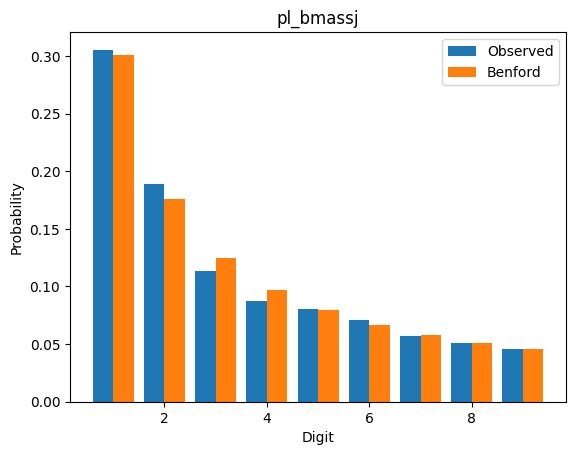


===== pl_orbper =====
Chi-square p-value: 0.0000
KS p-value: 0.9924
Pearson r: 0.9947
Spearman r: 0.9833
Kendall tau: 0.9444


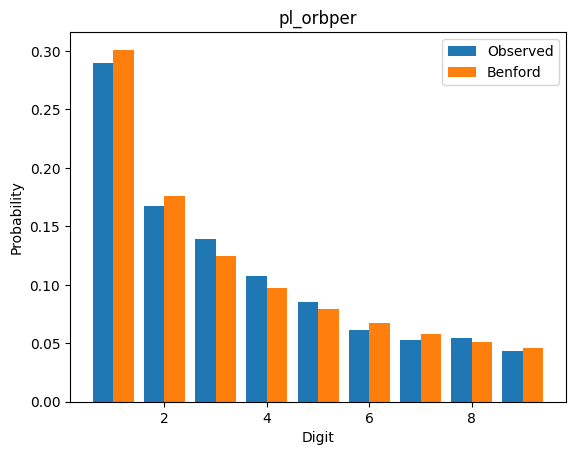


===== pl_orbsmax =====
Chi-square p-value: 0.0000
KS p-value: 0.9638
Pearson r: 0.9880
Spearman r: 1.0000
Kendall tau: 1.0000


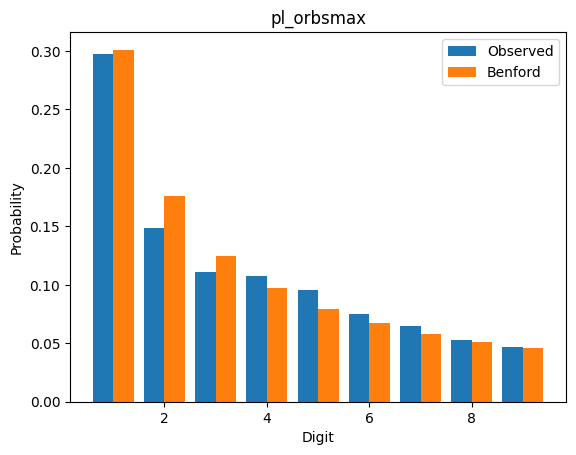


===== pl_radj =====
Chi-square p-value: 0.0000
KS p-value: 0.2235
Pearson r: 0.9595
Spearman r: 0.5167
Kendall tau: 0.3333


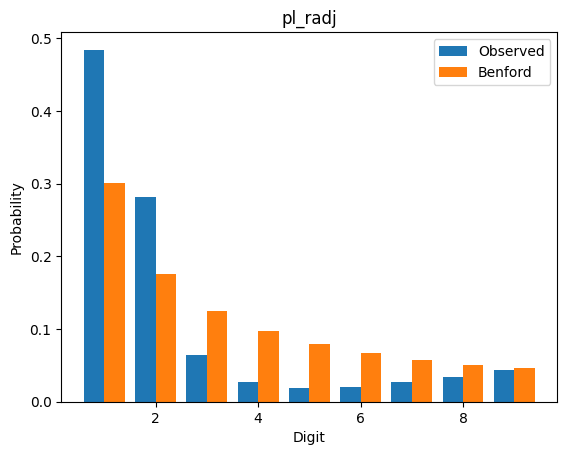


===== pl_eqt =====
Chi-square p-value: 0.0000
KS p-value: 0.4863
Pearson r: 0.7056
Spearman r: -0.0500
Kendall tau: -0.1111


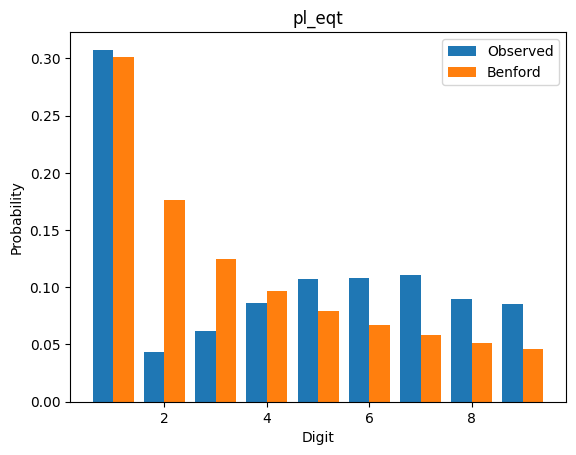


===== st_mass =====
Chi-square p-value: 0.0000
KS p-value: 0.2040
Pearson r: 0.5493
Spearman r: -0.3667
Kendall tau: -0.4444


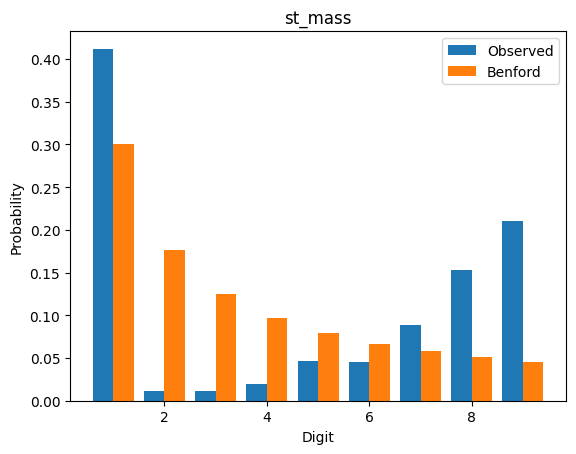


===== st_rad =====
Chi-square p-value: 0.0000
KS p-value: 0.2961
Pearson r: 0.6237
Spearman r: -0.3333
Kendall tau: -0.3889


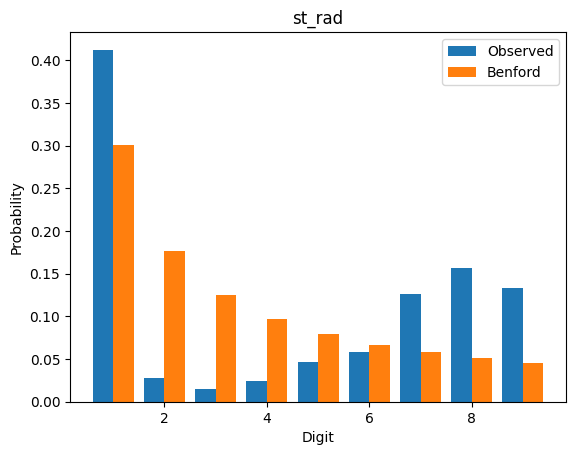


===== sy_dist =====
Chi-square p-value: 0.0000
KS p-value: 0.8244
Pearson r: 0.9326
Spearman r: 0.9500
Kendall tau: 0.8333


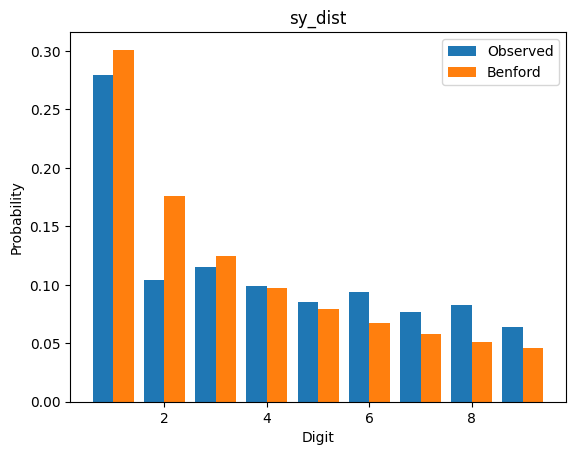

In [ ]:
benford = benford_distribution()

results = []

for col in columns:
    print(f"\n===== {col} =====")

    digits = get_digits(df[col])

    # skip small data
    if len(digits) < 50:
        print("Too few samples, skipping")
        continue

    obs = observed_distribution(digits)

    chi_p, ks_p, pearson_r, spearman_r, kendall_tau = run_tests(
        obs.values, digits, benford
    )

    print(f"Chi-square p-value: {chi_p:.4f}")
    print(f"KS p-value: {ks_p:.4f}")
    print(f"Pearson r: {pearson_r:.4f}")
    print(f"Spearman r: {spearman_r:.4f}")
    print(f"Kendall tau: {kendall_tau:.4f}")

    plot_dist(obs.values, benford, col)

    results.append([col, chi_p, ks_p, pearson_r, spearman_r, kendall_tau])

In [ ]:
summary = pd.DataFrame(results, columns=[
    "Feature", "Chi_p", "KS_p", "Pearson_r", "Spearman_r", "Kendall_tau"
])

print(summary)

      Feature         Chi_p      KS_p  Pearson_r  Spearman_r  Kendall_tau
0   pl_bmassj  1.769243e-03  0.994674   0.996583    1.000000     1.000000
1   pl_orbper  5.368278e-38  0.992433   0.994719    0.983333     0.944444
2  pl_orbsmax  6.687260e-55  0.963771   0.988025    1.000000     1.000000
3     pl_radj  0.000000e+00  0.223538   0.959511    0.516667     0.333333
4      pl_eqt  0.000000e+00  0.486323   0.705582   -0.050000    -0.111111
5     st_mass  0.000000e+00  0.203965   0.549289   -0.366667    -0.444444
6      st_rad  0.000000e+00  0.296107   0.623670   -0.333333    -0.388889
7     sy_dist  0.000000e+00  0.824448   0.932584    0.950000     0.833333
